In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/ramkiran23/poc-session/poc_session_01.mp4
/kaggle/input/datasets/ramkiran23/poc-session/poc_session_02.mp4
/kaggle/input/models/ramkiran23/detection-model/tfjs/default/1/1.tflite


In [2]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/datasets/ramkiran23/poc-session/poc_session_01.mp4
/kaggle/input/datasets/ramkiran23/poc-session/poc_session_02.mp4
/kaggle/input/models/ramkiran23/detection-model/tfjs/default/1/1.tflite


In [13]:
# ---- EDIT THIS CELL AFTER ATTACHING YOUR KAGGLE DATASET ----
from pathlib import Path

# Exact user-provided Kaggle input paths.
INPUT_ROOT = Path('/kaggle/input/datasets/ramkiran23/poc-session')
VIDEO_PATHS = [
    Path('/kaggle/input/datasets/ramkiran23/poc-session/poc_session_01.mp4'),
    Path('/kaggle/input/datasets/ramkiran23/poc-session/poc_session_02.mp4'),
]
# Run one fixed-camera session at a time. Set 0 for session 01 or 1 for session 02, then rerun from this cell.
SESSION_TO_RUN = 0
VIDEO_PATH = VIDEO_PATHS[SESSION_TO_RUN]
PERSON_MODEL_PATH = Path('/kaggle/input/models/ramkiran23/detection-model/tfjs/default/1/1.tflite')
OUTPUT_ROOT = Path('/kaggle/working/shopper_analytics') / VIDEO_PATH.stem
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

# This timestamp is used for time/day trends when the MP4 has no true capture timestamp.
VIDEO_START_ISO = {
    'poc_session_01.mp4': '2026-09-05T10:00:00+05:30',
    'poc_session_02.mp4': '2026-09-05T11:00:00+05:30',
}
MAX_FRAMES = None  # set e.g. 900 for a quick test
FRAME_STRIDE = 1   # 1 = every frame; use 2 only if the video is too slow
DETECTION_THRESHOLD = 0.45
PERSON_CLASS_ID = 0
NUM_THREADS = 4

# Replace these normalised coordinates after taking one screenshot from the final fixed camera position.
CALIBRATION = {
  'entry_line': {'p1': [0.08, 0.55], 'p2': [0.92, 0.55],
                 'enter_direction': 'positive_to_negative', 'cooldown_seconds': 2.0},
  'promo_zone': [[0.35, 0.30], [0.62, 0.30], [0.62, 0.88], [0.35, 0.88]],
  'promo_dwell_seconds': 8.0,
  'zones': {
      'entry_area': [[0.05, 0.40], [0.30, 0.40], [0.30, 0.95], [0.05, 0.95]],
      'promotion_display': [[0.35, 0.30], [0.62, 0.30], [0.62, 0.88], [0.35, 0.88]],
      'checkout_area': [[0.70, 0.45], [0.98, 0.45], [0.98, 0.95], [0.70, 0.95]],
  }
}

print({'videos': {path.name: path.exists() for path in VIDEO_PATHS}, 'model_exists': PERSON_MODEL_PATH.exists(), 'input': str(INPUT_ROOT)})

{'videos': {'poc_session_01.mp4': True, 'poc_session_02.mp4': True}, 'model_exists': True, 'input': '/kaggle/input/datasets/ramkiran23/poc-session'}


In [14]:
# Input audit — run this before inference.
import json

if not INPUT_ROOT.exists():
    raise FileNotFoundError(f'Update INPUT_ROOT: {INPUT_ROOT}')
for path in sorted(p for p in INPUT_ROOT.rglob('*') if p.is_file())[:50]:
    print(path.relative_to(INPUT_ROOT))
for video_path in VIDEO_PATHS:
    if not video_path.is_file(): raise FileNotFoundError(f'Video missing: {video_path}')
if not PERSON_MODEL_PATH.is_file(): raise FileNotFoundError(f'Model missing: {PERSON_MODEL_PATH}')
print('Input audit passed.')

poc_session_01.mp4
poc_session_02.mp4
Input audit passed.


In [15]:
import math
import uuid
from collections import defaultdict
from datetime import datetime, timedelta

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

def dequantize(value, detail):
    scale, zero_point = detail['quantization']
    return (value.astype(np.float32) - zero_point) * scale if scale else value.astype(np.float32)

class PersonDetector:
    def __init__(self, model_path):
        self.interpreter = tf.lite.Interpreter(model_path=str(model_path), num_threads=NUM_THREADS)
        self.interpreter.allocate_tensors()
        self.input = self.interpreter.get_input_details()[0]
        self.outputs = self.interpreter.get_output_details()
        self.h, self.w = self.input['shape'][1:3]
    def detect(self, frame):
        height, width = frame.shape[:2]
        rgb = cv2.cvtColor(cv2.resize(frame, (self.w, self.h)), cv2.COLOR_BGR2RGB)
        normal = rgb.astype(np.float32) / 255.0
        scale, zero = self.input['quantization']
        if self.input['dtype'] == np.float32: value = normal
        elif scale:
            info = np.iinfo(self.input['dtype'])
            value = np.clip(np.round(normal / scale + zero), info.min, info.max).astype(self.input['dtype'])
        else: value = rgb.astype(self.input['dtype'])
        self.interpreter.set_tensor(self.input['index'], value[None, ...]); self.interpreter.invoke()
        values = [dequantize(self.interpreter.get_tensor(item['index']), item) for item in self.outputs]
        boxes, classes, scores = values[0][0], values[1][0], values[2][0]
        result = []
        for box, cls, score in zip(boxes, classes, scores):
            if int(round(cls)) != PERSON_CLASS_ID or score < DETECTION_THRESHOLD: continue
            y1, x1, y2, x2 = box
            x1, x2 = sorted((max(0, int(x1*width)), min(width, int(x2*width))))
            y1, y2 = sorted((max(0, int(y1*height)), min(height, int(y2*height))))
            if x2 > x1 and y2 > y1: result.append((x1, y1, x2, y2, float(score)))
        return result

def centre(box):
    return ((box[0]+box[2])/2, (box[1]+box[3])/2)

class Tracker:
    def __init__(self, maximum_distance=100, maximum_misses=12):
        self.maximum_distance, self.maximum_misses, self.next_id, self.tracks = maximum_distance, maximum_misses, 1, {}
    def update(self, boxes):
        centres, remaining = [centre(box) for box in boxes], set(range(len(boxes)))
        for tid, track in list(self.tracks.items()):
            distances = [math.dist(track['centre'], value) if i in remaining else float('inf') for i, value in enumerate(centres)]
            best = int(np.argmin(distances)) if distances else -1
            if best >= 0 and distances[best] <= self.maximum_distance:
                track.update(centre=centres[best], box=boxes[best], misses=0); remaining.remove(best)
            else:
                track['misses'] += 1
                if track['misses'] > self.maximum_misses: del self.tracks[tid]
        for index in remaining:
            self.tracks[self.next_id] = {'centre': centres[index], 'box': boxes[index], 'misses': 0,
                'last_side': None, 'last_cross_seconds': -1e9, 'zones': set(),
                'promo_started_seconds': None, 'promo_alerted': False}
            self.next_id += 1
        return self.tracks

In [16]:
def px(point, width, height): return int(point[0]*width), int(point[1]*height)
def side_of_line(point, a, b):
    return 1 if (b[0]-a[0])*(point[1]-a[1]) - (b[1]-a[1])*(point[0]-a[0]) >= 0 else -1

cap = cv2.VideoCapture(str(VIDEO_PATH))
if not cap.isOpened(): raise RuntimeError(f'Cannot open {VIDEO_PATH}')
fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
width, height = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)), int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
print(f'Video: {width}x{height} @ {fps:.2f} FPS')

line_a, line_b = px(CALIBRATION['entry_line']['p1'], width, height), px(CALIBRATION['entry_line']['p2'], width, height)
promo_polygon = np.array([px(point, width, height) for point in CALIBRATION['promo_zone']], np.int32)
zone_polygons = {name: np.array([px(point, width, height) for point in points], np.int32)
                 for name, points in CALIBRATION['zones'].items()}

detector, tracker = PersonDetector(PERSON_MODEL_PATH), Tracker()
events, heatmap, entered, exited, frame_index = [], np.zeros((height, width), np.float32), 0, 0, 0
video_start = datetime.fromisoformat(VIDEO_START_ISO[VIDEO_PATH.name])

def add_event(event_type, video_seconds, **payload):
    events.append({'event_id': str(uuid.uuid4()), 'timestamp': (video_start + timedelta(seconds=video_seconds)).isoformat(),
                   'video_seconds': round(video_seconds, 2), 'event_type': event_type, 'camera_id': 'poc_single_camera', **payload})

while cap.isOpened():
    ok, frame = cap.read()
    if not ok or (MAX_FRAMES is not None and frame_index >= MAX_FRAMES): break
    frame_index += 1
    if frame_index % FRAME_STRIDE: continue
    seconds = frame_index / fps
    tracks = tracker.update(detector.detect(frame))
    heatmap *= 0.998
    for tid, track in tracks.items():
        if track['misses']: continue
        point = track['centre']; cv2.circle(heatmap, (int(point[0]), int(point[1])), 20, 1.0, -1)
        side = side_of_line(point, line_a, line_b)
        if track['last_side'] is not None and side != track['last_side'] and seconds-track['last_cross_seconds'] >= CALIBRATION['entry_line']['cooldown_seconds']:
            direction = 'positive_to_negative' if track['last_side'] > side else 'negative_to_positive'
            event_type = 'ENTRY' if direction == CALIBRATION['entry_line']['enter_direction'] else 'EXIT'
            if event_type == 'ENTRY': entered += 1
            else: exited += 1
            add_event(event_type, seconds, anonymous_track=tid, entered=entered, exited=exited)
            track['last_cross_seconds'] = seconds
        track['last_side'] = side
        active_zones = {name for name, polygon in zone_polygons.items() if cv2.pointPolygonTest(polygon, point, False) >= 0}
        for zone in active_zones - track['zones']: add_event('ZONE_ENTRY', seconds, anonymous_track=tid, zone=zone)
        for zone in track['zones'] - active_zones: add_event('ZONE_EXIT', seconds, anonymous_track=tid, zone=zone)
        track['zones'] = active_zones
        if cv2.pointPolygonTest(promo_polygon, point, False) >= 0:
            track['promo_started_seconds'] = track['promo_started_seconds'] or seconds
            dwell = seconds - track['promo_started_seconds']
            if dwell >= CALIBRATION['promo_dwell_seconds'] and not track['promo_alerted']:
                add_event('PROMO_DWELL', seconds, anonymous_track=tid, dwell_seconds=round(dwell, 1))
                track['promo_alerted'] = True
        elif track['promo_started_seconds'] is not None:
            add_event('PROMO_EXIT', seconds, anonymous_track=tid, dwell_seconds=round(seconds-track['promo_started_seconds'], 1))
            track['promo_started_seconds'], track['promo_alerted'] = None, False
cap.release()
print(f'Processed {frame_index} frames | IN={entered}, OUT={exited}, events={len(events)}')

Video: 1920x1080 @ 29.97 FPS


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Processed 240 frames | IN=0, OUT=0, events=8


In [17]:
# Save dashboard-ready, anonymous outputs. No frames are written to disk.
# Copy the exact tested person detector into Kaggle Output for the laptop real-time runner.
import shutil
LOCAL_PERSON_MODEL = OUTPUT_ROOT / '1.tflite'
shutil.copy2(PERSON_MODEL_PATH, LOCAL_PERSON_MODEL)
events_df = pd.DataFrame(events)
events_df.to_csv(OUTPUT_ROOT / 'shopper_events.csv', index=False)
(OUTPUT_ROOT / 'shopper_events.json').write_text(json.dumps(events, indent=2))

if not events_df.empty:
    events_df['timestamp'] = pd.to_datetime(events_df['timestamp'])
    footfall_by_hour = (events_df[events_df.event_type == 'ENTRY'].assign(hour=lambda d: d.timestamp.dt.hour)
                        .groupby('hour').size().rename('entries').reset_index())
    zone_footfall = (events_df[events_df.event_type == 'ZONE_ENTRY'].groupby('zone').size()
                     .rename('entries').reset_index())
    promo_dwell = events_df[events_df.event_type == 'PROMO_DWELL'].copy()
else:
    footfall_by_hour, zone_footfall, promo_dwell = pd.DataFrame(), pd.DataFrame(), pd.DataFrame()
footfall_by_hour.to_csv(OUTPUT_ROOT / 'footfall_by_hour.csv', index=False)
zone_footfall.to_csv(OUTPUT_ROOT / 'zone_footfall.csv', index=False)
promo_dwell.to_csv(OUTPUT_ROOT / 'promo_dwell.csv', index=False)

summary = {'entered': entered, 'exited': exited, 'estimated_inside': max(0, entered-exited),
           'events': len(events), 'video': VIDEO_PATH.name, 'fps': fps}
(OUTPUT_ROOT / 'shopper_summary.json').write_text(json.dumps(summary, indent=2))
print('Download this for real-time laptop analytics:', LOCAL_PERSON_MODEL)
summary

Download this for real-time laptop analytics: /kaggle/working/shopper_analytics/poc_session_01/1.tflite


{'entered': 0,
 'exited': 0,
 'estimated_inside': 0,
 'events': 8,
 'video': 'poc_session_01.mp4',
 'fps': 29.97002997002997}

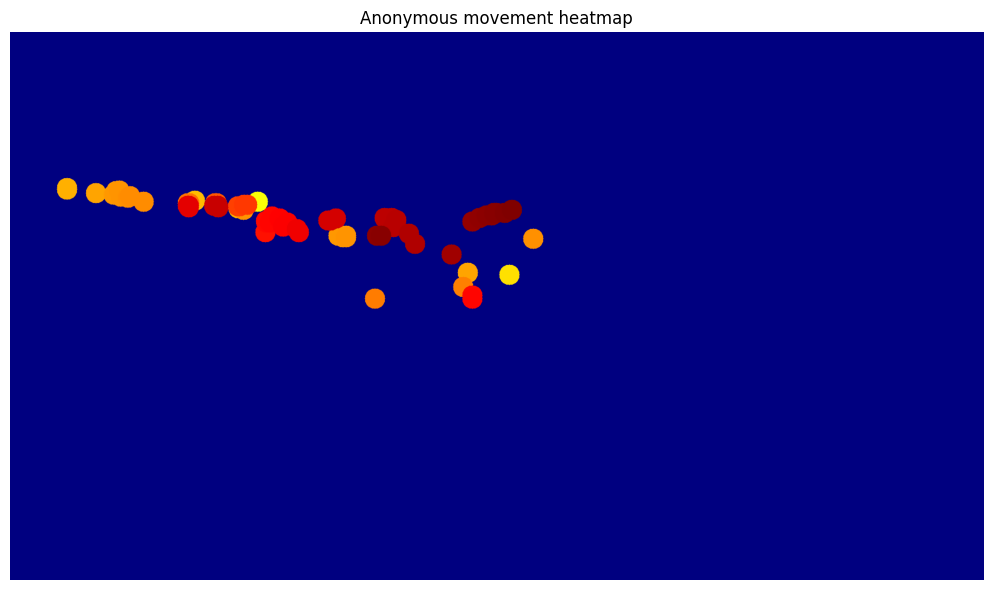

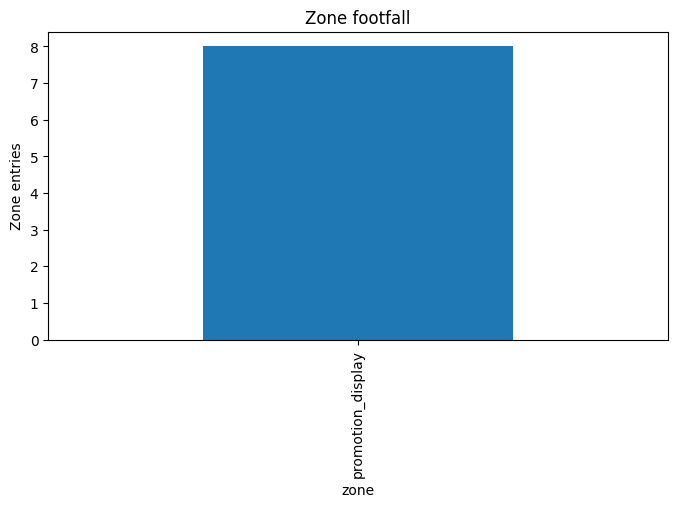

Outputs: ['footfall_by_hour.csv', 'shopper_summary.json', 'shopper_events.csv', '1.tflite', 'shopper_events.json', 'movement_heatmap.png', 'promo_dwell.csv', 'zone_footfall.csv']


In [18]:
# Movement heatmap and trend charts for the dashboard/report.
heat8 = cv2.normalize(heatmap, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
plt.figure(figsize=(12, 6)); plt.imshow(cv2.applyColorMap(heat8, cv2.COLORMAP_JET)[..., ::-1]); plt.title('Anonymous movement heatmap'); plt.axis('off')
plt.tight_layout(); plt.savefig(OUTPUT_ROOT / 'movement_heatmap.png', dpi=150); plt.show()
if not footfall_by_hour.empty:
    footfall_by_hour.plot(kind='bar', x='hour', y='entries', legend=False, title='Footfall by hour', figsize=(8, 4)); plt.ylabel('Entries'); plt.show()
if not zone_footfall.empty:
    zone_footfall.plot(kind='bar', x='zone', y='entries', legend=False, title='Zone footfall', figsize=(8, 4)); plt.ylabel('Zone entries'); plt.show()
print('Outputs:', [path.name for path in OUTPUT_ROOT.iterdir()])